Maratona de programação : Hackathon com o tema: "Detecção de Cicatrizes de Queimadas com Dados de Sensoriamento Remoto".

A arquitetura do modelo combina rede UNet com enconder baseado em Vison Transformer (ViT).
Também utiliza canal de entrada extra como o indice dNBRSWIR.
O treinamento possui uma função que utiliza uma combinação de funções de perda (BCE e Dice Loss) e uma estratégia de parada antecipada (Early Stopping) para garantir o melhor desempenho e evitar o overfitting.

Grupo do projeto:

Victoria Roberta
- Linkedin: https://www.linkedin.com/in/vict%C3%B3ria-roberta-0a4a4917b/

João Lucas Anselmo
- Linkedin: https://www.linkedin.com/in/jo%C3%A3o-lucas-012595169/



Instalação e importação de dependências

In [1]:
!pip install -q timm rasterio spyndex torch torchvision

# Imports
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import timm
import rasterio
from rasterio import plot
import spyndex
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.8/769.8 kB 37.4 MB/s eta 0:00:00


Montagem do drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Prepara o  Dataset Siamese

In [3]:
class SiameseDataset(Dataset):
    def __init__(self, T10_dir, T20_dir, mask_dir, transform=None):
        self.T10_dir = T10_dir
        self.T20_dir = T20_dir
        self.mask_dir = mask_dir
        self.transform = transform

        self.ids = sorted([
            f.split('_')[-1].replace('.tif', '')
            for f in os.listdir(T10_dir)
            if f.startswith('recorte_') and
               os.path.isfile(os.path.join(T20_dir, f)) and
               os.path.isfile(os.path.join(mask_dir, f))
        ])

    def __len__(self):
        return len(self.ids)

    def read_image(self, path):
        with rasterio.open(path) as src:
            img = src.read().astype(np.float32)  # shape (C, H, W)
            img = np.nan_to_num(img, nan=0.0)
            img_min = img.min()
            img_max = img.max()
            if img_max - img_min > 0:
                img = (img - img_min) / (img_max - img_min)
            else:
                img = np.zeros_like(img)
        return torch.tensor(img, dtype=torch.float32)

    def read_mask(self, path):
        with rasterio.open(path) as src:
            mask = src.read(1).astype(np.float32)
            mask = np.nan_to_num(mask, nan=0.0)
            mask = np.where(mask > 0, 1.0, 0.0)
        return torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

    def __getitem__(self, idx):
        id_ = self.ids[idx]
        fname = f"recorte_{id_}.tif"
        T10_path = os.path.join(self.T10_dir, fname)
        T20_path = os.path.join(self.T20_dir, fname)
        mask_path = os.path.join(self.mask_dir, fname)

        t1 = self.read_image(T10_path)  # (4,H,W)
        t2 = self.read_image(T20_path)
        mask = self.read_mask(mask_path)

        if self.transform:
            t1 = self.transform(t1)
            t2 = self.transform(t2)
            mask = self.transform(mask)

        return t1, t2, mask


Cálculo do Índice dNBRSWIR

In [4]:
def compute_nbrswir(img):
    S1 = img[2].astype(np.float32)  # SWIR1
    S2 = img[3].astype(np.float32)  # SWIR2
    # spyndex formula NBRSWIR: (S2 - S1 -0.02)/(S2 + S1 + 0.1) per baseline
    nbr = (S2 - S1 - 0.02) / (S2 + S1 + 0.1 + 1e-8)
    return nbr

def compute_dnbrswir(img_t1, img_t2):
    return compute_nbrswir(img_t1) - compute_nbrswir(img_t2)


Arquitetura do Modelo

A rede é uma Siamese U-Net com um codificador (encoder) baseado em Vision Transformer (ViT)

In [5]:
# DoubleConv similar ao seu baseline
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

# Encoder que usa um ViT (timm). Ele retorna um mapa espacial (B, C, H_p, W_p)
class ViTSpatialEncoder(nn.Module):
    def __init__(self, model_name='vit_small_patch16_224', pretrained=True, in_chans=4):
        super().__init__()
        # tenta criar modelo timm (pode ser DINO-weighted se timm tiver)
        self.vit = timm.create_model(model_name, pretrained=pretrained)
        # adapt patch_embed conv para in_chans
        try:
            proj = self.vit.patch_embed.proj  # conv2d
            new_proj = nn.Conv2d(in_chans, proj.out_channels, kernel_size=proj.kernel_size,
                                 stride=proj.stride, padding=proj.padding, bias=False)
            # inicialização: copiar média dos pesos RGB para 4º canal
            with torch.no_grad():
                if proj.weight.shape[1] >= 3:
                    w = proj.weight.clone()
                    if in_chans == 4:
                        # copiar média do canal R,G,B para canal 4
                        fourth = w[:, :3, :, :].mean(dim=1, keepdim=True)
                        new_proj.weight[:, :3, :, :] = w[:, :3, :, :]
                        new_proj.weight[:, 3:4, :, :] = fourth
                else:
                    nn.init.kaiming_normal_(new_proj.weight, mode='fan_out', nonlinearity='relu')
            self.vit.patch_embed.proj = new_proj
        except Exception as e:
            print("⚠️ Aviso adapt patch embed:", e)

    def forward(self, x):
        # x: (B, C=4, H, W). Queremos obter um mapa espacial em resolução H/4 x W/4 (depende do patch size)
        B, C, H, W = x.shape

        # 1) Patch embed (conv)
        x = self.vit.patch_embed.proj(x)             # (B, embed_dim, H_p, W_p)
        x = x.flatten(2).transpose(1,2)              # (B, N_patches, embed_dim)
        # 2) add pos embedding and pass through blocks to get final tokens
        x = x + self.vit.patch_embed.cls_token if False else x  # safe no-op (some models different)
        # Use vit.blocks to transform tokens
        # Note: timm ViT expects patch_embed.proj output then pos_embed + blocks; we emulate minimal behavior
        # Add positional embedding (interpolate if needed)
        try:
            pos = self.vit.pos_embed
            if pos is not None:
                # pos shape (1, N+1, D) maybe, we assume no CLS pos or handle slice
                pos_tokens = pos
                # If shapes mismatch, skip (positional handling is model-specific)
        except Exception:
            pass

        # apply blocks
        for blk in self.vit.blocks:
            x = blk(x)
        x = self.vit.norm(x)  # (B, N_patches, embed_dim)

        # reshape tokens back to spatial map
        N = x.shape[1]
        # infer grid size
        gp = int(np.sqrt(N))
        feat = x.transpose(1,2).contiguous().view(B, -1, gp, gp)  # (B, D, gp, gp)
        return feat  # spatial map at patch resolution (gp x gp)

# U-Net decoder that expects encoder maps at H/4 x W/4 to reconstruct H x W
class DecoderUNet(nn.Module):
    def __init__(self, enc_ch, extra_channels=1):
        super().__init__()
        in_c = 2*enc_ch + extra_channels

        self.conv1 = DoubleConv(in_c, 256)
        self.up1   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 8→16
        self.conv2 = DoubleConv(256, 128)
        self.up2   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 16→32
        self.conv3 = DoubleConv(128, 64)
        self.up3   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 32→64
        self.conv4 = DoubleConv(64, 32)
        self.up4   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)  # 64→128
        self.final = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, feat1, feat2, extra_map):
        x = torch.cat([feat1, feat2, extra_map], dim=1)  # concat canais
        x = self.conv1(x)
        x = self.up1(x)
        x = self.conv2(x)
        x = self.up2(x)
        x = self.conv3(x)
        x = self.up3(x)
        x = self.conv4(x)
        x = self.up4(x)
        x = self.final(x)
        return torch.sigmoid(x)

# Full siamese model
class SiameseViTUNet(nn.Module):
    def __init__(self, vit_name='vit_small_patch16_224', pretrained=True, in_chans=4):
        super().__init__()
        self.encoder = ViTSpatialEncoder(model_name=vit_name, pretrained=pretrained, in_chans=in_chans)

        self.decoder = None
        self._enc_out_ch = None

    def build_decoder(self, enc_out_ch, extra_channels=1):
        self._enc_out_ch = enc_out_ch
        self.decoder = DecoderUNet(enc_out_ch, extra_channels)

    def forward(self, x1, x2, extra_map):
        # x1,x2: (B,4,H,W), extra_map: (B,1,gp,gp)
        f1 = self.encoder(x1)  # (B, D, gp, gp)
        f2 = self.encoder(x2)
        if self.decoder is None:
            raise RuntimeError("Call build_decoder(enc_out_ch) after model init with correct enc_out_ch")
        out = self.decoder(f1, f2, extra_map)
        # If output size < target (H,W) maybe we need interpolation
        return out


Validação do modelo


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


model = SiameseViTUNet(vit_name='vit_small_patch16_224', pretrained=True, in_chans=4).to(device)


H,W = 128,128
with torch.no_grad():
    dummy = torch.zeros(1,4,H,W).to(device)
    feat = model.encoder(dummy)
    enc_ch = feat.shape[1]
    gp = feat.shape[2]
    print("Encoder output channels:", enc_ch, "grid:", gp)
model.build_decoder(enc_out_ch=enc_ch, extra_channels=1)
model.to(device)

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Encoder output channels: 384 grid: 8


SiameseViTUNet(
  (encoder): ViTSpatialEncoder(
    (vit): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(4, 384, kernel_size=(16, 16), stride=(16, 16), bias=False)
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (ml

Carrega os dados de treinamento

Os dados disponibilizados no hackaton foram transferidos para o drive pessoal


In [7]:
t1_dir = "/content/drive/MyDrive/dataset_kaggle/dataset/t1"
t2_dir = "/content/drive/MyDrive/dataset_kaggle/dataset/t2"
mask_dir = "/content/drive/MyDrive/dataset_kaggle/dataset/mask"

dataset = SiameseDataset(t1_dir, t2_dir, mask_dir)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2, pin_memory=True)


import torch.nn.functional as F
def make_extra_map(t1, t2, gp):
    # t1,t2: tensors (B,4,H,W) on CPU or GPU
    B = t1.shape[0]
    extra = []
    for i in range(B):
        img1 = t1[i].cpu().numpy()
        img2 = t2[i].cpu().numpy()
        dn = compute_dnbrswir(img1, img2)  # (H,W)
        extra.append(dn)
    extra = np.stack(extra, axis=0).astype(np.float32)  # (B,H,W)
    extra_t = torch.tensor(extra).unsqueeze(1).to(device)  # (B,1,H,W)
    # downsample to gp x gp
    extra_ds = F.interpolate(extra_t, size=(gp,gp), mode='bilinear', align_corners=False)
    return extra_ds


Função de perda e treinamento

In [8]:
def dice_loss(pred, target, eps=1e-6):
    num = 2*(pred*target).sum(dim=(1,2,3))
    den = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    loss = 1 - (num/den)
    return loss.mean()

# Função de perda (BCE + Dice)
def dice_loss(pred, target, eps=1e-6):
    num = 2*(pred*target).sum(dim=(1,2,3))
    den = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps
    loss = 1 - (num/den)
    return loss.mean()

# Treino por época
def train_one_epoch(model, loader, optimizer, device, gp):
    model.train()
    total_loss = 0
    for t1, t2, mask in loader:
        t1, t2, mask = t1.to(device), t2.to(device), mask.to(device)
        extra = make_extra_map(t1, t2, gp)  # (B,1,gp,gp)

        pred = model(t1, t2, extra)  # já sai em 128x128

        bce = F.binary_cross_entropy(pred, mask)
        dloss = dice_loss(pred, mask)
        loss = bce + dloss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Avaliação (AUC-ROC)
def eval_model(model, loader, device, gp):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for t1, t2, mask in loader:
            t1, t2, mask = t1.to(device), t2.to(device), mask.to(device)
            extra = make_extra_map(t1, t2, gp)
            pred = model(t1, t2, extra)  # já sai 128x128

            all_labels.extend(mask.cpu().numpy().ravel())
            all_preds.extend(pred.cpu().numpy().ravel())

    auc = roc_auc_score(all_labels, all_preds)
    fpr, tpr, thr = roc_curve(all_labels, all_preds)
    return auc, fpr, tpr, thr



Primeiro treinamento com 10 épocas

In [10]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
# descobrir gp (grid) que usamos quando inferimos encoder dummy antes
gp = feat.shape[2]
n_epochs = 10

for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device, gp)
    auc, fpr, tpr, thr = eval_model(model, test_loader, device, gp)
    print(f"Epoch {epoch+1}/{n_epochs} - TrainLoss: {train_loss:.4f} - Val AUC: {auc:.4f}")

# salvar modelo
torch.save(model.state_dict(), "/content/sample_data/siamese_vit_unet.pth")
print("Modelo salvo em /content/sample_data/siamese_vit_unet.pth")


Epoch 1/10 - TrainLoss: 1.1078 - Val AUC: 0.4769
Epoch 2/10 - TrainLoss: 1.0931 - Val AUC: 0.4790
Epoch 3/10 - TrainLoss: 1.0825 - Val AUC: 0.4999
Epoch 4/10 - TrainLoss: 1.0562 - Val AUC: 0.9230
Epoch 5/10 - TrainLoss: 0.9710 - Val AUC: 0.9538
Epoch 6/10 - TrainLoss: 0.9236 - Val AUC: 0.9537
Epoch 7/10 - TrainLoss: 0.8966 - Val AUC: 0.9567
Epoch 8/10 - TrainLoss: 0.8739 - Val AUC: 0.9183
Epoch 9/10 - TrainLoss: 0.8557 - Val AUC: 0.9510
Epoch 10/10 - TrainLoss: 0.8371 - Val AUC: 0.9156
Modelo salvo em /content/sample_data/siamese_vit_unet.pth


Segundo treino pra aplicar a logica de Early Stopping, onde treinamos por 50 epocas e o loop vai identificando a melhor e salvando, ou seja, o valor atual de auc é comparado com o best_val_auc salvo.

In [11]:
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

gp = feat.shape[2]
n_epochs = 30  # 30 épocas para treino

# --- Parâmetros para Early Stopping ---
patience = 5  # O modelo irá esperar 5 épocas por uma melhora
best_val_auc = -1.0  # Começa com um valor baixo para garantir que a primeira época salve o modelo
epochs_no_improve = 0
best_model_path = "/content/siamese_vit_unet_best.pth"

# --- Início do loop de treinamento ---
for epoch in range(n_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, device, gp)
    auc, fpr, tpr, thr = eval_model(model, test_loader, device, gp)
    print(f"Epoch {epoch+1}/{n_epochs} - TrainLoss: {train_loss:.4f} - Val AUC: {auc:.4f}")

    # Lógica de Early Stopping
    if auc > best_val_auc:
        print("Melhora no Val AUC! Salvando o modelo...")
        best_val_auc = auc
        epochs_no_improve = 0
        # Salva o estado do modelo (os pesos) quando houver melhora
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
        print(f"Val AUC não melhorou por {epochs_no_improve} épocas.")
        if epochs_no_improve >= patience:
            print("Parando o treinamento: limite de paciência atingido!")
            break

# Após o loop, o melhor modelo salvo está em best_model_path
print(f"✅ Treinamento concluído. O melhor modelo está salvo em '{best_model_path}'.")


Epoch 1/30 - TrainLoss: 0.8215 - Val AUC: 0.9609
Melhora no Val AUC! Salvando o modelo...
Epoch 2/30 - TrainLoss: 0.8075 - Val AUC: 0.9715
Melhora no Val AUC! Salvando o modelo...
Epoch 3/30 - TrainLoss: 0.8015 - Val AUC: 0.9662
Val AUC não melhorou por 1 épocas.
Epoch 4/30 - TrainLoss: 0.7934 - Val AUC: 0.9612
Val AUC não melhorou por 2 épocas.
Epoch 5/30 - TrainLoss: 0.7839 - Val AUC: 0.9756
Melhora no Val AUC! Salvando o modelo...
Epoch 6/30 - TrainLoss: 0.7676 - Val AUC: 0.9641
Val AUC não melhorou por 1 épocas.
Epoch 7/30 - TrainLoss: 0.7647 - Val AUC: 0.9733
Val AUC não melhorou por 2 épocas.
Epoch 8/30 - TrainLoss: 0.7517 - Val AUC: 0.9731
Val AUC não melhorou por 3 épocas.
Epoch 9/30 - TrainLoss: 0.7502 - Val AUC: 0.9665
Val AUC não melhorou por 4 épocas.
Epoch 10/30 - TrainLoss: 0.7384 - Val AUC: 0.9776
Melhora no Val AUC! Salvando o modelo...
Epoch 11/30 - TrainLoss: 0.7320 - Val AUC: 0.9785
Melhora no Val AUC! Salvando o modelo...
Epoch 12/30 - TrainLoss: 0.7239 - Val AUC: 0

Visualização dos resultados com modelo de Curva ROC

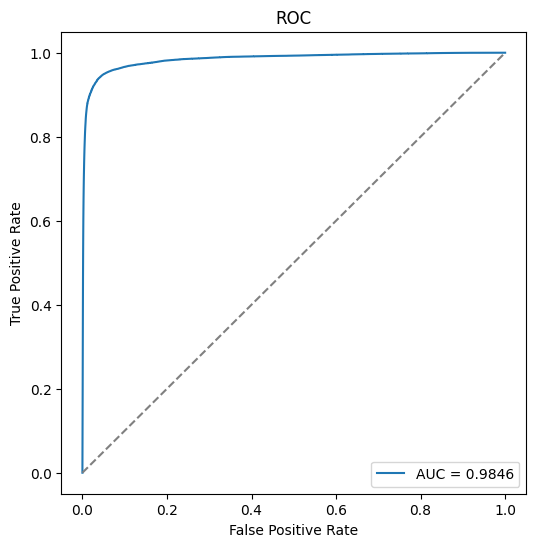

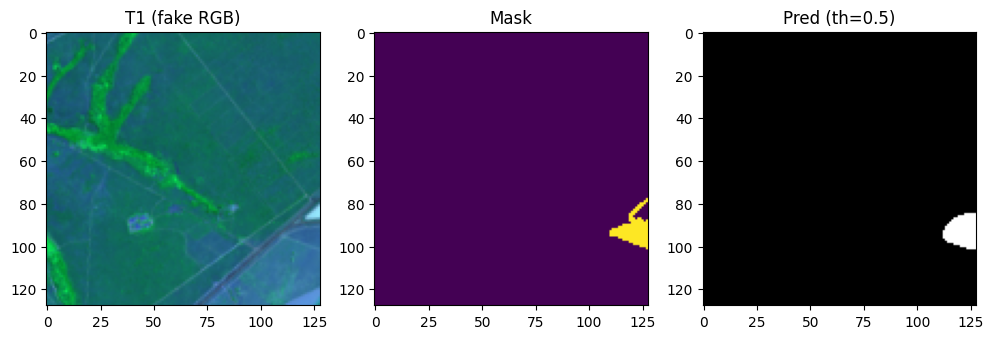

In [12]:
# Célula 9 - ROC plot e viz
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC")
plt.show()

# mostra um exemplo
t1, t2, mask = next(iter(test_loader))
extra = make_extra_map(t1, t2, gp)
pred = model(t1.to(device), t2.to(device), extra)
pred_up = F.interpolate(pred, size=mask.shape[-2:], mode='bilinear', align_corners=False).cpu().detach().numpy()
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(t1[0,:3].permute(1,2,0)); plt.title("T1 (fake RGB)")
plt.subplot(1,3,2); plt.imshow(mask[0,0]); plt.title("Mask")
plt.subplot(1,3,3); plt.imshow(pred_up[0,0] > 0.5, cmap='gray'); plt.title("Pred (th=0.5)")
plt.show()


In [13]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recria a arquitetura exatamente como no treino
H, W = 128, 128
model = SiameseViTUNet(vit_name='vit_small_patch16_224', pretrained=False, in_chans=4).to(device)

# Rodar dummy para inicializar encoder/decoder
with torch.no_grad():
    dummy = torch.zeros(1, 4, H, W).to(device)
    feat = model.encoder(dummy)
    enc_ch = feat.shape[1]

model.build_decoder(enc_out_ch=enc_ch, extra_channels=1)
model.to(device)

# Carregar pesos treinados
model.load_state_dict(torch.load("/content/siamese_vit_unet_best.pth", map_location=device))
model.eval()


SiameseViTUNet(
  (encoder): ViTSpatialEncoder(
    (vit): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(4, 384, kernel_size=(16, 16), stride=(16, 16), bias=False)
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=384, out_features=1152, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=384, out_features=384, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): Identity()
          (drop_path1): Identity()
          (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
          (ml

Preparação do modelo para exportação em csv

In [38]:
import os
import csv
import torch
import rasterio
import numpy as np
import torch.nn.functional as F

# Defina a função de normalização
def read_image(path):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
    img = np.nan_to_num(img, nan=0.0)
    img_min = img.min()
    img_max = img.max()
    if img_max - img_min > 0:
        img = (img - img_min) / (img_max - img_min)
    else:
        img = np.zeros_like(img)
    return torch.tensor(img, dtype=torch.float32)

def compute_nbrswir(img):
    S1 = img[2].astype(np.float32)  # SWIR1
    S2 = img[3].astype(np.float32)  # SWIR2
    nbr = (S2 - S1) / (S2 + S1 + 1e-8)
    return nbr

def compute_dnbrswir(img_t1, img_t2):
    return compute_nbrswir(img_t1) - compute_nbrswir(img_t2)

def make_extra_map(t1, t2, gp):
    B = t1.shape[0]
    extra = []
    for i in range(B):
        img1 = t1[i].cpu().numpy()
        img2 = t2[i].cpu().numpy()
        dn = compute_dnbrswir(img1, img2)
        extra.append(dn)
    extra = np.stack(extra, axis=0).astype(np.float32)
    extra_t = torch.tensor(extra).unsqueeze(1).to(t1.device)
    extra_ds = F.interpolate(extra_t, size=(gp, gp), mode='bilinear', align_corners=False)
    return extra_ds

# Replicando a arquitetura do modelo
# Certifique-se de que as classes DoubleConv, ViTSpatialEncoder, DecoderUNet, e SiameseViTUNet
# estão disponíveis no seu ambiente. Você pode copiar e colar as definições delas
# do seu notebook original.

# Exemplo de definição para garantir que o código funcione
class DoubleConv(torch.nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = torch.nn.Sequential(
            torch.nn.Conv2d(in_c, out_c, 3, padding=1),
            torch.nn.BatchNorm2d(out_c),
            torch.nn.ReLU(inplace=True),
            torch.nn.Conv2d(out_c, out_c, 3, padding=1),
            torch.nn.BatchNorm2d(out_c),
            torch.nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class ViTSpatialEncoder(torch.nn.Module):
    def __init__(self, model_name='vit_small_patch16_224', pretrained=True, in_chans=4):
        super().__init__()
        self.vit = timm.create_model(model_name, pretrained=pretrained)
        proj = self.vit.patch_embed.proj
        new_proj = torch.nn.Conv2d(in_chans, proj.out_channels, kernel_size=proj.kernel_size,
                                   stride=proj.stride, padding=proj.padding, bias=False)
        with torch.no_grad():
            if proj.weight.shape[1] >= 3:
                w = proj.weight.clone()
                if in_chans == 4:
                    fourth = w[:, :3, :, :].mean(dim=1, keepdim=True)
                    new_proj.weight[:, :3, :, :] = w[:, :3, :, :]
                    new_proj.weight[:, 3:4, :, :] = fourth
        self.vit.patch_embed.proj = new_proj
    def forward(self, x):
        B, C, H, W = x.shape
        x = self.vit.patch_embed.proj(x)
        x = x.flatten(2).transpose(1, 2)
        for blk in self.vit.blocks:
            x = blk(x)
        x = self.vit.norm(x)
        N = x.shape[1]
        gp = int(np.sqrt(N))
        feat = x.transpose(1, 2).contiguous().view(B, -1, gp, gp)
        return feat

class DecoderUNet(torch.nn.Module):
    def __init__(self, enc_ch, extra_channels=1):
        super().__init__()
        in_c = 2 * enc_ch + extra_channels
        self.conv1 = DoubleConv(in_c, 256)
        self.up1 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv2 = DoubleConv(256, 128)
        self.up2 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv3 = DoubleConv(128, 64)
        self.up3 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.conv4 = DoubleConv(64, 32)
        self.up4 = torch.nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.final = torch.nn.Conv2d(32, 1, kernel_size=1)
    def forward(self, feat1, feat2, extra_map):
        x = torch.cat([feat1, feat2, extra_map], dim=1)
        x = self.conv1(x)
        x = self.up1(x)
        x = self.conv2(x)
        x = self.up2(x)
        x = self.conv3(x)
        x = self.up3(x)
        x = self.conv4(x)
        x = self.up4(x)
        x = self.final(x)
        return torch.sigmoid(x)

class SiameseViTUNet(torch.nn.Module):
    def __init__(self, vit_name='vit_small_patch16_224', pretrained=True, in_chans=4):
        super().__init__()
        self.encoder = ViTSpatialEncoder(model_name=vit_name, pretrained=pretrained, in_chans=in_chans)
        self.decoder = None
        self._enc_out_ch = None
    def build_decoder(self, enc_out_ch, extra_channels=1):
        self._enc_out_ch = enc_out_ch
        self.decoder = DecoderUNet(enc_out_ch, extra_channels)
    def forward(self, x1, x2, extra_map):
        f1 = self.encoder(x1)
        f2 = self.encoder(x2)
        if self.decoder is None:
            raise RuntimeError("Call build_decoder(enc_out_ch) after model init with correct enc_out_ch")
        out = self.decoder(f1, f2, extra_map)
        return out

# ==============================
# 1. Preparar modelo
# ==============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

H, W = 128, 128
model = SiameseViTUNet(vit_name='vit_small_patch16_224', pretrained=False, in_chans=4).to(device)

with torch.no_grad():
    dummy = torch.zeros(1, 4, H, W).to(device)
    feat = model.encoder(dummy)
    enc_ch = feat.shape[1]
    gp = feat.shape[2]

model.build_decoder(enc_out_ch=enc_ch, extra_channels=1)
model.load_state_dict(torch.load("/content/siamese_vit_unet_best.pth", map_location=device))
model.to(device)
model.eval()
print("Modelo carregado e pronto para inferência")

# ==============================
# 2. Dados de entrada
# ==============================
t1_dir = "/content/drive/MyDrive/dataset_kaggle/avaliacao/t1"
t2_dir = "/content/drive/MyDrive/dataset_kaggle/avaliacao/t2"

files_t1 = sorted(os.listdir(t1_dir))
files_t2 = sorted(os.listdir(t2_dir))

assert len(files_t1) == len(files_t2)

# ==============================
# 3. Gerar submissão em CSV
# ==============================
csv_path = "predicted_change_masks.csv"

with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)

    # Header: id + pixels flatten
    # Correção: Usar a função read_image para o sample
    t1_sample = read_image(os.path.join(t1_dir, files_t1[0])).unsqueeze(0).to(device)
    t2_sample = read_image(os.path.join(t2_dir, files_t2[0])).unsqueeze(0).to(device)

    extra = make_extra_map(t1_sample, t2_sample, gp)
    with torch.no_grad():
        pred_example = model(t1_sample, t2_sample, extra)

    num_pixels = pred_example[0, 0].numel()
    header = ["id"] + [f"pixel_{i}" for i in range(num_pixels)]
    writer.writerow(header)

    # Iterar sobre os pares T1/T2
    for idx, (f1, f2) in enumerate(zip(files_t1, files_t2)):
        id_sample = f1

        # Correção: Usar a função read_image para cada arquivo de avaliação
        t1 = read_image(os.path.join(t1_dir, f1)).unsqueeze(0).to(device)
        t2 = read_image(os.path.join(t2_dir, f2)).unsqueeze(0).to(device)

        extra = make_extra_map(t1, t2, gp)
        with torch.no_grad():
            pred = model(t1, t2, extra)
            pred_mask = (pred > 0.5).int().cpu().numpy().flatten()

        row = [id_sample] + pred_mask.tolist()
        writer.writerow(row)

print(f"Arquivo de submissão salvo em: {csv_path}")

Modelo carregado e pronto para inferência
Arquivo de submissão salvo em: predicted_change_masks.csv


Plotagem do csv

In [39]:
import pandas as pd

pd.read_csv('predicted_change_masks.csv')

,id,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_16374,pixel_16375,pixel_16376,pixel_16377,pixel_16378,pixel_16379,pixel_16380,pixel_16381,pixel_16382,pixel_16383
0,recorte_1.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,recorte_10.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,recorte_100.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,recorte_101.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,recorte_102.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310,recorte_95.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
311,recorte_96.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
312,recorte_97.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
313,recorte_98.tif,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
